In [ ]:
%pip install langchain-google-genai

In [6]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [7]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.7,
)

In [8]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation:str

In [9]:
def generate_joke(state:JokeState):
    prompt = f"generate a joke on the topic {state['topic']}"
    response = llm.invoke(prompt).content
    return {'joke': response}

In [10]:
def generate_explanation(state:JokeState):
    prompt = f"Write an explanation for the joke - {state['joke']}"
    response = llm.invoke(prompt).content
    return {'joke': response}

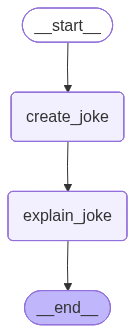

In [13]:
graph = StateGraph(JokeState)

graph.add_node('create_joke', generate_joke)
graph.add_node('explain_joke', generate_explanation)

graph.add_edge(START, 'create_joke')
graph.add_edge('create_joke', 'explain_joke')
graph.add_edge('explain_joke', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [14]:
config1 = {"configurable":{"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config = config1)

{'topic': 'pizza',
 'joke': 'This joke is a classic example of a **pun**, relying on a word with two different meanings.\n\n1.  **"Dough" (Literal Meaning):** In the context of pizza, "dough" refers to the soft, uncooked mixture of flour, water, and yeast that forms the base of the pizza. A pizza literally *is* made from dough.\n\n2.  **"Dough" (Slang Meaning):** "Dough" is also a very common slang term for **money**. When someone "gets a job," their primary goal is to "make some dough" (i.e., earn money).\n\nThe humor comes from the unexpected shift in meaning. The setup makes you think of a pizza being made *from* dough, but the punchline cleverly uses the *other* meaning of "dough" (money) to explain why a *person* would get a job. The absurdity of a pizza needing to earn money is what makes the wordplay funny!'}

In [15]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'This joke is a classic example of a **pun**, relying on a word with two different meanings.\n\n1.  **"Dough" (Literal Meaning):** In the context of pizza, "dough" refers to the soft, uncooked mixture of flour, water, and yeast that forms the base of the pizza. A pizza literally *is* made from dough.\n\n2.  **"Dough" (Slang Meaning):** "Dough" is also a very common slang term for **money**. When someone "gets a job," their primary goal is to "make some dough" (i.e., earn money).\n\nThe humor comes from the unexpected shift in meaning. The setup makes you think of a pizza being made *from* dough, but the punchline cleverly uses the *other* meaning of "dough" (money) to explain why a *person* would get a job. The absurdity of a pizza needing to earn money is what makes the wordplay funny!'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f15687a-490c-61ad-8002-94f372fb6cec'}}, metadata={'source':

In [16]:
# four values will be generated 1.before start, 2.after start with topic, 3.after joke generated, 4.after joke and explanation generated
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'This joke is a classic example of a **pun**, relying on a word with two different meanings.\n\n1.  **"Dough" (Literal Meaning):** In the context of pizza, "dough" refers to the soft, uncooked mixture of flour, water, and yeast that forms the base of the pizza. A pizza literally *is* made from dough.\n\n2.  **"Dough" (Slang Meaning):** "Dough" is also a very common slang term for **money**. When someone "gets a job," their primary goal is to "make some dough" (i.e., earn money).\n\nThe humor comes from the unexpected shift in meaning. The setup makes you think of a pizza being made *from* dough, but the punchline cleverly uses the *other* meaning of "dough" (money) to explain why a *person* would get a job. The absurdity of a pizza needing to earn money is what makes the wordplay funny!'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f15687a-490c-61ad-8002-94f372fb6cec'}}, metadata={'source'

## TIME TRAVEL

In [17]:
workflow.get_state({"configurable": {"thread_id": "1"}, "checkpoint_id":"1f156879-c8d0-6906-8000-09b3d7cc5878"})


StateSnapshot(values={'topic': 'pizza', 'joke': 'This joke is a classic example of a **pun**, relying on a word with two different meanings.\n\n1.  **"Dough" (Literal Meaning):** In the context of pizza, "dough" refers to the soft, uncooked mixture of flour, water, and yeast that forms the base of the pizza. A pizza literally *is* made from dough.\n\n2.  **"Dough" (Slang Meaning):** "Dough" is also a very common slang term for **money**. When someone "gets a job," their primary goal is to "make some dough" (i.e., earn money).\n\nThe humor comes from the unexpected shift in meaning. The setup makes you think of a pizza being made *from* dough, but the punchline cleverly uses the *other* meaning of "dough" (money) to explain why a *person* would get a job. The absurdity of a pizza needing to earn money is what makes the wordplay funny!'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f15687a-490c-61ad-8002-94f372fb6cec'}}, metadata={'source':

In [20]:
# i can re run from that checkpoint without any initial state
workflow.invoke(None, config={"configurable": {"thread_id": 1}, "checkpoint_id": "1f156879-c8d0-6906-8000-09b3d7cc5878"})

{'topic': 'pizza',
 'joke': 'This is a classic pun! Here\'s why it\'s funny:\n\n1.  **"Dough" (meaning 1): Slang for Money.** When people "get a job," they do so to "make money." "Dough" is a common, informal term for money (e.g., "I need to make some dough this month to pay the bills"). So, the pizza getting a job to "make some dough" sounds like a human needing to earn money.\n\n2.  **"Dough" (meaning 2): The Ingredient.** "Dough" also literally refers to the main ingredient of pizza – the mixture of flour, water, and yeast that forms the base before it\'s baked.\n\nThe humor comes from the unexpected twist: The joke sets you up to think about the pizza needing to earn money (like a person), but then uses "dough" to also refer to what the pizza *is made of*. It\'s a clever play on words that works because "dough" has two very different, but equally relevant, meanings in this context.'}

In [25]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'This is a classic **pun!**\n\nHere\'s the breakdown:\n\n1.  **The Setup:** The person tried to limit themselves to just one samosa.\n2.  **The Pun:** The word "samosa" is used to sound like the word "say."\n3.  **The Punchline:** "I just couldn\'t **samosa** no!" is a play on the common idiom, "I just couldn\'t **say** no!"\n\n**Meaning of the Joke:**\n\nThe joke implies that the samosas were so delicious and tempting that the person simply couldn\'t resist eating more than just one. They tried to "say no" to another samosa, but their willpower failed because the samosas were too good!\n\nIt\'s funny because it cleverly replaces a common word ("say") with the subject of the sentence ("samosa") to create an unexpected and relatable piece of wordplay.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1568bd-2285-64ee-8004-499ed655f4c1'}}, metadata={'source': 'loop', 'step': 4, 'parents': {}},

In [ ]:
# can change topic in that checkpoint and run 
workflow.invoke({'topic': 'samosa'}, config={"configurable": {"thread_id": "1"}, "checkpoint_id": "1f156879-c8d0-6906-8000-09b3d7cc5878"})

{'topic': 'samosa',
 'joke': 'This is a classic **pun!**\n\nHere\'s the breakdown:\n\n1.  **The Setup:** The person tried to limit themselves to just one samosa.\n2.  **The Pun:** The word "samosa" is used to sound like the word "say."\n3.  **The Punchline:** "I just couldn\'t **samosa** no!" is a play on the common idiom, "I just couldn\'t **say** no!"\n\n**Meaning of the Joke:**\n\nThe joke implies that the samosas were so delicious and tempting that the person simply couldn\'t resist eating more than just one. They tried to "say no" to another samosa, but their willpower failed because the samosas were too good!\n\nIt\'s funny because it cleverly replaces a common word ("say") with the subject of the sentence ("samosa") to create an unexpected and relatable piece of wordplay.'}